## Answer the questions from the introduction
#### What is leave-one-out? Provide limitations and strengths.

проходимся по каждому элементу, его делаем валидационным и на нем же тестируем, так с каждым элементом выборки

\+ работает полностью со всеми данными

\+ детерминирован

\- большие затраты

#### How do Grid Search, Randomized Grid Search, and Bayesian optimization work?


grid search - перебор заранее заданных параметров по сетке, проверяет каждую комбинацию

rand grid search - выбирает рандомные комбинации параметров вместо перебора всех

байесовская опимизация - выбираются случайные точки на распределении, далее строится аппроксимация и рядом с аапроксимацией распределение вероятностей возможных функций, дальше с помощью функций сбора выбирается след точка, и тд

#### Explain classification of feature selection methods. Explain how Pearson and Chi2 work. Explain how Lasso works. Explain what permutation significance is. Become familiar with SHAP.

we have supervised and unsupervised feature selection methods

for supervised we have wrappers, filters and embedded

filters are looking at each feature apart, they dont know about feature correlation

wrappers dont find the best or the worst feature, they find the best combination of features

and we already know about embedded, for example, lasso regularization

pearson is cov / sqrt(D1 * D2). if its equals to 0 - there are no corr. if its 1 correlation is positive and vice versa

we use chi2 for categories. chi2 is (real - expected)**2 / expected. this is how we get chi2 and then we should compare it with critical point. if chi2 is less than critical point then difference between features statistically insignificant

i have lasso explanation in ML2 project

 permutation significance is when we use permutations of features to empirically measure how the feature affect on accuracy

## Introduction — do all the preprocessing from the previous lesson


#### Read all the data.

In [1]:
from itertools import product
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold
import lightgbm
import scipy
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.pipeline import Pipeline
import shap
import optuna

C:\Users\130\school_21_ds_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pd.read_json('data/train.json')
low = train['price'].quantile(0.01)
high = train['price'].quantile(0.99)
train = train.copy()[(train['price'] > low) & (train['price'] < high)].copy()
train['created'] = pd.to_datetime(train['created'])

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48343 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   bathrooms        48343 non-null  float64       
 1   bedrooms         48343 non-null  int64         
 2   building_id      48343 non-null  object        
 3   created          48343 non-null  datetime64[ns]
 4   description      48343 non-null  object        
 5   display_address  48343 non-null  object        
 6   features         48343 non-null  object        
 7   latitude         48343 non-null  float64       
 8   listing_id       48343 non-null  int64         
 9   longitude        48343 non-null  float64       
 10  manager_id       48343 non-null  object        
 11  photos           48343 non-null  object        
 12  price            48343 non-null  int64         
 13  street_address   48343 non-null  object        
 14  interest_level   48343 non-null  object   

In [4]:
train['features'] = (train['features'].astype(str).str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace("'", "", regex=False).str.replace('"', '', regex=False).str.replace(' ', '', regex=False))
big_list = []

In [5]:
for i, row in train.iterrows():
    for i in row['features'].split(','):
        if i.strip():
            big_list.append(i.strip())
counts = Counter(big_list)
most_common_features = counts.most_common(20)

In [6]:
features = []
for i in most_common_features:
    features.append(i[0])
features_series = pd.Series(features, name = 'features')
features_series

0              Elevator
1        HardwoodFloors
2           CatsAllowed
3           DogsAllowed
4               Doorman
5            Dishwasher
6                 NoFee
7     LaundryinBuilding
8         FitnessCenter
9               Pre-War
10        LaundryinUnit
11             RoofDeck
12         OutdoorSpace
13           DiningRoom
14    HighSpeedInternet
15              Balcony
16         SwimmingPool
17    LaundryInBuilding
18      NewConstruction
19              Terrace
Name: features, dtype: object

In [7]:
y_train = train['price']
train = train[['bathrooms', 'bedrooms', 'features', 'created']]
train
mega_df = train['features'].str.get_dummies(sep=',')[features]
mega_df

,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,0,1,1,1,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0
6,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
9,1,1,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
15,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
124002,1,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
124004,1,1,1,1,0,1,1,1,0,1,1,0,0,1,0,0,0,0,0,0
124008,0,0,0,0,0,1,1,0,0,1,1,0,1,0,0,0,0,0,0,0


In [8]:
train = train.drop(columns='features')
X_train = pd.concat([train, mega_df], axis=1)
X_train

,bathrooms,bedrooms,created,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,2016-06-16 05:55:27,0,1,1,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,2016-06-01 05:44:33,1,1,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,2016-06-14 15:19:59,1,1,0,0,1,1,0,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,2016-06-24 07:54:24,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,2016-06-28 03:50:23,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,2016-04-05 03:58:33,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
124002,1.0,2,2016-04-02 02:25:31,1,0,1,1,1,0,1,...,0,0,0,0,0,0,0,1,0,0
124004,1.0,1,2016-04-26 05:42:03,1,1,1,1,0,1,1,...,1,0,0,1,0,0,0,0,0,0
124008,1.0,2,2016-04-19 02:47:33,0,0,0,0,0,1,1,...,1,0,1,0,0,0,0,0,0,0


In [9]:
iqr_bedrooms_train = X_train['bedrooms'].quantile(0.75) - X_train['bedrooms'].quantile(0.25)
lower = X_train['bedrooms'].quantile(0.25) - 1.5 * iqr_bedrooms_train
higher = X_train['bedrooms'].quantile(0.75) + 1.5 * iqr_bedrooms_train
mask = (X_train['bedrooms'] < higher) & (X_train['bedrooms'] > lower)
X_data = X_train[mask]
y_data = y_train[mask]
X_data

,bathrooms,bedrooms,created,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,2016-06-16 05:55:27,0,1,1,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,2016-06-01 05:44:33,1,1,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,2016-06-14 15:19:59,1,1,0,0,1,1,0,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,2016-06-24 07:54:24,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,2016-06-28 03:50:23,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,2016-04-05 03:58:33,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
124002,1.0,2,2016-04-02 02:25:31,1,0,1,1,1,0,1,...,0,0,0,0,0,0,0,1,0,0
124004,1.0,1,2016-04-26 05:42:03,1,1,1,1,0,1,1,...,1,0,0,1,0,0,0,0,0,0
124008,1.0,2,2016-04-19 02:47:33,0,0,0,0,0,1,1,...,1,0,1,0,0,0,0,0,0,0


## Implement the next methods:

#### Split data into 2 parts randomly with parameter test_size (ratio from 0 to 1), return training and test samples.

In [10]:
def my_train_test_split(X, y, test_size=0.2, random_state=21):
    np.random.seed(random_state)
    indexes = np.random.permutation(X.shape[0])
    n = len(X)
    train = indexes[int(n*test_size):]
    test = indexes[:int(n*test_size)]

    X_train = X.iloc[train]
    X_test = X.iloc[test]

    y_train = y.iloc[train]
    y_test = y.iloc[test]

    return X_train, X_test, y_train, y_test

#### Randomly split data into 3 parts with parameters validation_size and test_size, return train, validation and test samples.

In [11]:
def my_train_valid_test_split(X, y, validation_size=0.2, test_size=0.2, random_state=21):
    np.random.seed(random_state)
    indexes = np.random.permutation(X.shape[0])
    n = len(X)
    valid = indexes[:int(validation_size*n)]
    test = indexes[int(validation_size*n):int(validation_size*n) + int(test_size * n)]
    train = indexes[int(validation_size*n) + int(test_size * n):]

    X_valid = X.iloc[valid]
    y_valid = y.iloc[valid]
    X_train = X.iloc[train]
    X_test = X.iloc[test]
    y_train = y.iloc[train]
    y_test = y.iloc[test]

    return X_train, X_valid, X_test, y_train, y_valid, y_test

#### Split data into 2 parts with parameter date_split, return train and test samples split by date_split param.

In [12]:
def my_train_test_date_split(X, y, date_split):
    train_mask = X['created'] < date_split

    X_train = X[train_mask]
    X_test = X[~train_mask]

    y_train = y[train_mask]
    y_test = y[~train_mask]

    X_train = X_train.drop(columns=['created'])
    X_test = X_test.drop(columns=['created'])

    return X_train, X_test, y_train, y_test

#### Split data into 3 parts with parameters validation_date and test_date, return train, validation and test samples split by input params.


In [13]:
def my_train_valid_test_date_split(X, y, validation_date=0.2, test_date=0.2):
    train_mask = X['created'] < validation_date
    valid_mask = (X['created'] >= validation_date) & (X['created'] <= test_date)
    test_mask = X['created'] > test_date

    X_train = X[train_mask]
    X_valid = X[valid_mask]
    X_test = X[test_mask]

    y_train = y[train_mask]
    y_valid = y[valid_mask]
    y_test = y[test_mask]

    return X_train, X_valid, X_test, y_train, y_valid, y_test

## 4. Implement the next cross-validation methods:

#### K-Fold, where k is the input parameter, returns a list of train and test indices.


In [14]:
class MyKFold():
    def __init__(self, k_splits, random_state=21, shuffle=False):
        self.k_splits = k_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X):
        np.random.seed(self.random_state)
        indexes = np.arange(X.shape[0])
        if self.shuffle:
            np.random.shuffle(indexes)
        fold = len(indexes) // self.k_splits
        for i in range(self.k_splits):
            start = i * fold
            if i != self.k_splits - 1:
                end = (i + 1) * fold
            else:
                end = len(indexes)
            test_idx = indexes[start:end]
            train_idx = np.concatenate([indexes[:start], indexes[end:]])
            yield  train_idx, test_idx

In [15]:
KFC = MyKFold(5)
for train_index, test_index in KFC.split(X_data):
    print(train_index)
    print(test_index)

[ 9263  9264  9265 ... 46314 46315 46316]
[   0    1    2 ... 9260 9261 9262]
[    0     1     2 ... 46314 46315 46316]
[ 9263  9264  9265 ... 18523 18524 18525]
[    0     1     2 ... 46314 46315 46316]
[18526 18527 18528 ... 27786 27787 27788]
[    0     1     2 ... 46314 46315 46316]
[27789 27790 27791 ... 37049 37050 37051]
[    0     1     2 ... 37049 37050 37051]
[37052 37053 37054 ... 46314 46315 46316]


#### Grouped K-Fold, where k and group_field are input parameters, returns list of train and test indices.

In [16]:
class MyGroupedKFold():
    def __init__(self, k_splits, group_field, random_state=21, shuffle=False):
        self.k_splits = k_splits
        self.group_field = group_field
        self.unique_groups = np.unique(group_field)
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X):
        np.random.seed(self.random_state)
        if self.shuffle:
            np.random.shuffle(self.unique_groups)
        group_folds = np.array_split(self.unique_groups, self.k_splits)
        for i in range(self.k_splits):
            test_group = group_folds[i]
            test_mask = np.isin(self.group_field, test_group)
            test_indexes = np.where(test_mask)[0]
            train_group = np.concatenate(group_folds[:i] + group_folds[i + 1:])
            train_mask = np.isin(self.group_field, train_group)
            train_indexes = np.where(train_mask)[0]
            yield train_indexes, test_indexes

#### Stratified K-fold, where k and stratify_field are input parameters, returns list of train and test indices.

In [17]:
class MyStratifiedKFold():
    def __init__(self, k_splits, stratify_field, random_state=21, shuffle=False):
        self.k_splits = k_splits
        self.stratify_field = stratify_field
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X):
        np.random.seed(self.random_state)
        unique_classes, counts = np.unique(self.stratify_field, return_counts=True)
        all_class_splits = []
        for i in range(len(unique_classes)):
            current_class_indexes = np.where(self.stratify_field == unique_classes[i])[0]
            splited_class = np.array_split(current_class_indexes, self.k_splits)
            all_class_splits.append(splited_class)
        all_idx = np.arange(len(self.stratify_field))
        for i in range(self.k_splits):
            test_indexes = np.concatenate([class_part[i] for class_part in all_class_splits])
            train_indexes = np.setdiff1d(all_idx, test_indexes)
            yield train_indexes, test_indexes


#### Time series split, where k and date_field are input parameters, returns list of train and test indices.

In [18]:
class MyTimeSeriesSplit():
    def __init__(self, k_splits, date_field):
        self.k_splits = k_splits
        self.date_field = date_field

    def split(self, X):
        sorted_indexes = np.argsort(self.date_field)
        folds = np.array_split(sorted_indexes, self.k_splits + 1)
        for i in range(self.k_splits):
            test_indexes = folds[i+1]
            train_indexes = np.concatenate(folds[:i + 1])
            yield train_indexes, test_indexes

## 5 Cross-validation comparison



#### Apply all the validation methods implemented above to our dataset. To apply Stratified algorithm you should preprocess target.

In [19]:
X_train, X_test, y_train, y_test = my_train_test_split(X_data, y_data, test_size=0.2)
print(f"Total: {len(X_data)}")
print(f"Train: {len(X_train)} ({len(X_train)/len(X_data):.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X_data):.1%})")

Total: 46317
Train: 37054 (80.0%)
Test:  9263 (20.0%)


In [20]:
X_train, X_test, y_train, y_test = my_train_test_date_split(X_data, y_data, '2016-05-15 03:20:33')
print(f"Total: {len(X_data)}")
print(f"Train: {len(X_train)} ({len(X_train)/len(X_data):.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X_data):.1%})")

Total: 46317
Train: 22881 (49.4%)
Test:  23436 (50.6%)


In [21]:
X_train, X_valid, X_test, y_train, y_valid, y_test = my_train_valid_test_split(X=X_data, y=y_data, validation_size=0.2, test_size=0.2)
print(f"Total: {len(X_data)}")
print(f"Train: {len(X_train)} ({len(X_train)/len(X_data):.1%})")
print(f"Valid: {len(X_valid)} ({len(X_valid)/len(X_data):.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X_data):.1%})")

Total: 46317
Train: 27791 (60.0%)
Valid: 9263 (20.0%)
Test:  9263 (20.0%)


In [22]:
X_train, X_valid, X_test, y_train, y_valid, y_test = my_train_valid_test_date_split(X=X_data, y=y_data, validation_date='2016-05-15 03:20:33', test_date='2016-06-01 03:20:33')
print(f"Total: {len(X_data)}")
print(f"Train: {len(X_train)} ({len(X_train)/len(X_data):.1%})")
print(f"Valid: {len(X_valid)} ({len(X_valid)/len(X_data):.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X_data):.1%})")

Total: 46317
Train: 22881 (49.4%)
Valid: 7554 (16.3%)
Test:  15882 (34.3%)


In [23]:
X_train, X_test, y_train, y_test = my_train_test_split(X_data, y_data, test_size=0.2)
print(f"Total: {len(X_data)}")
print(f"Train: {len(X_train)} ({len(X_train)/len(X_data):.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X_data):.1%})")

Total: 46317
Train: 37054 (80.0%)
Test:  9263 (20.0%)


In [24]:
KFC = MyKFold(5)
for train_index, test_index in KFC.split(X_data):
    print(train_index)
    print(test_index)

[ 9263  9264  9265 ... 46314 46315 46316]
[   0    1    2 ... 9260 9261 9262]
[    0     1     2 ... 46314 46315 46316]
[ 9263  9264  9265 ... 18523 18524 18525]
[    0     1     2 ... 46314 46315 46316]
[18526 18527 18528 ... 27786 27787 27788]
[    0     1     2 ... 46314 46315 46316]
[27789 27790 27791 ... 37049 37050 37051]
[    0     1     2 ... 37049 37050 37051]
[37052 37053 37054 ... 46314 46315 46316]


In [25]:
GKF = MyGroupedKFold(k_splits=4, group_field=X_data['bedrooms'])
for train_index, test_index in GKF.split(X_data):
    print(train_index)
    print(test_index)

print(X_data['bedrooms'].unique())

[    0     1     2 ... 46314 46315 46316]
[    4     7    10 ... 46300 46304 46311]
[    1     2     3 ... 46313 46315 46316]
[    0     8    13 ... 46309 46310 46314]
[    0     3     4 ... 46312 46314 46316]
[    1     2    11 ... 46308 46313 46315]
[    0     1     2 ... 46313 46314 46315]
[    3     5     6 ... 46307 46312 46316]
[1 2 3 0]


In [26]:
for train_index, test_index in GKF.split(X_data):
    unique_test_groups = X_data.iloc[test_index]['bedrooms'].unique()
    print(f" кол во спален {unique_test_groups}  строк {len(test_index)}")

 кол во спален [0]  строк 9200
 кол во спален [1]  строк 15528
 кол во спален [2]  строк 14534
 кол во спален [3]  строк 7055


In [27]:
### stratif and timeseries

In [28]:
SKF = MyStratifiedKFold(k_splits=5, stratify_field=y_data)
for train_index, test_index in SKF.split(X_data):
    print(train_index)
    print(test_index)

[  595  1005  1253 ... 46314 46315 46316]
[27218 23527    31 ... 21426 26102 26473]
[    0     1     2 ... 46314 46315 46316]
[23545 25665 27298 ... 19972 44481 27678]
[    0     1     2 ... 46314 46315 46316]
[30496 31249 33124 ... 21412 23592 33179]
[    0     1     2 ... 46314 46315 46316]
[35884 37354 37872 ... 33529 27268 42143]
[    0     1     2 ... 46268 46270 46284]
[41379 42599 45191 ... 42241 44299 46069]


In [29]:
for train_index, test_index in SKF.split(y_data):
    dist = y_data.iloc[test_index].value_counts(normalize=True)
    print(f"доли в дате:\n{dist}")

доли в дате:
price
2500     0.020533
3200     0.016166
3000     0.015516
2700     0.014494
2400     0.014401
           ...   
11340    0.000093
1601     0.000093
1599     0.000093
1597     0.000093
1590     0.000093
Name: proportion, Length: 2558, dtype: float64
доли в дате:
price
2500    0.023098
3200    0.018186
3000    0.017454
2700    0.016200
2400    0.016095
          ...   
1580    0.000105
1489    0.000105
1565    0.000105
1558    0.000105
9600    0.000105
Name: proportion, Length: 1527, dtype: float64
доли в дате:
price
2500     0.024668
3200     0.019422
3000     0.018529
2700     0.017301
2400     0.017189
           ...   
3249     0.000112
10250    0.000112
3255     0.000112
10570    0.000112
6240     0.000112
Name: proportion, Length: 1056, dtype: float64
доли в дате:
price
2500    0.025608
3200    0.020046
3000    0.019235
2700    0.017961
2400    0.017845
          ...   
1710    0.000116
8400    0.000116
8395    0.000116
2845    0.000116
2842    0.000116
Name: proport

In [30]:
TSS = MyTimeSeriesSplit(k_splits=5, date_field=X_data['created'])
for train_index, test_index in TSS.split(X_data):
    print(len(train_index))
    print(len(test_index))

7720
7720
15440
7720
23160
7719
30879
7719
38598
7719


C:\Users\130\school_21_ds_1\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


In [31]:
sklearn_KFC = KFold(n_splits=5)
for train_index, test_index in sklearn_KFC.split(X_data):
    print(train_index)
    print(test_index)

[ 9264  9265  9266 ... 46314 46315 46316]
[   0    1    2 ... 9261 9262 9263]
[    0     1     2 ... 46314 46315 46316]
[ 9264  9265  9266 ... 18525 18526 18527]
[    0     1     2 ... 46314 46315 46316]
[18528 18529 18530 ... 27788 27789 27790]
[    0     1     2 ... 46314 46315 46316]
[27791 27792 27793 ... 37051 37052 37053]
[    0     1     2 ... 37051 37052 37053]
[37054 37055 37056 ... 46314 46315 46316]


In [32]:
sklearn_GKF = GroupKFold(n_splits=4)
for train_index, test_index in sklearn_GKF.split(X_data, groups=X_data['bedrooms']):
    unique_test_groups = X_data.iloc[test_index]['bedrooms'].unique()
    print(f" кол во спален {unique_test_groups}  строк {len(test_index)}")

 кол во спален [1]  строк 15528
 кол во спален [2]  строк 14534
 кол во спален [0]  строк 9200
 кол во спален [3]  строк 7055


подойдут обычные train test split и k fold, остальные методы будут либо мешать либо будут излишни

## 6.Feature Selection

#### Fit a Lasso regression model with normalized features. Use your method for splitting samples into 3 parts by field created with 60/20/20 ratio — train/validation/test.

In [33]:
X = X_data.drop(['created'], axis=1)
X

,bathrooms,bedrooms,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,0,1,1,1,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,1,1,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,1,1,0,0,1,1,0,1,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
124002,1.0,2,1,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
124004,1.0,1,1,1,1,1,0,1,1,1,...,1,0,0,1,0,0,0,0,0,0
124008,1.0,2,0,0,0,0,0,1,1,0,...,1,0,1,0,0,0,0,0,0,0


In [34]:
y = y_data
y

4         2400
6         3800
9         3495
10        3000
15        2795
          ... 
124000    2800
124002    2395
124004    1850
124008    4195
124009    4280
Name: price, Length: 46317, dtype: int64

In [35]:
minmaxsc = MinMaxScaler()
lasso = Lasso(random_state=21)
pipe = Pipeline([('min_max_scaler', minmaxsc), ('lasso', lasso)])

In [36]:
X_train, X_valid, X_test, y_train, y_valid, y_test = my_train_valid_test_split(X=X, y=y, validation_size=0.2, test_size=0.2, random_state=21)

In [37]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('min_max_scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [38]:
predict = pipe.predict(X_test)

In [39]:
MAE = mean_absolute_error(y_test, predict)
RMSE = np.sqrt(mean_squared_error(y_test, predict))
R2 = r2_score(y_test, predict)
print(MAE)
print(RMSE)
print(R2)

691.8559233686669
1004.7127687415165
0.5341880914382817


#### Sort features by weight coefficients from model, fit model to top 10 features and compare quality.

In [40]:
lasso_model = pipe.named_steps['lasso']

In [41]:
weights = lasso_model.coef_
feature_names = X_train.columns
feat_coef = {x: y for x, y in zip(feature_names, weights)}
coef_ceries = pd.Series(feat_coef)
coef_ceries

bathrooms            15092.976352
bedrooms              1374.505888
Elevator               210.441159
HardwoodFloors        -181.178196
CatsAllowed            -20.750678
DogsAllowed            102.500506
Doorman                607.446937
Dishwasher             141.948506
NoFee                 -119.328769
LaundryinBuilding     -203.007278
FitnessCenter          240.991403
Pre-War                -35.355022
LaundryinUnit          447.261540
RoofDeck               -95.787637
OutdoorSpace           -90.261026
DiningRoom             100.462509
HighSpeedInternet     -234.605229
Balcony                 -5.979531
SwimmingPool             0.438587
LaundryInBuilding     -340.874261
NewConstruction        -88.415814
Terrace                167.077804
dtype: float64

In [42]:
top = coef_ceries.abs().sort_values(ascending=False)[:10]
top_coeffs = top.index
top_coeffs = list(top_coeffs)
top_coeffs

['bathrooms',
 'bedrooms',
 'Doorman',
 'LaundryinUnit',
 'LaundryInBuilding',
 'FitnessCenter',
 'HighSpeedInternet',
 'Elevator',
 'LaundryinBuilding',
 'HardwoodFloors']

In [43]:
X_new = X[top_coeffs]
X_new

,bathrooms,bedrooms,Doorman,LaundryinUnit,LaundryInBuilding,FitnessCenter,HighSpeedInternet,Elevator,LaundryinBuilding,HardwoodFloors
4,1.0,1,0,0,0,0,0,0,1,1
6,1.0,2,1,0,0,0,0,1,1,1
9,1.0,2,1,1,0,0,0,1,1,1
10,1.5,3,0,0,0,0,0,0,0,0
15,1.0,0,1,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,0,0,0,0,0,1,0,1
124002,1.0,2,1,0,1,0,0,1,0,0
124004,1.0,1,0,1,0,0,0,1,1,1
124008,1.0,2,0,1,0,0,0,0,0,0


In [44]:
X_train, X_valid, X_test, y_train, y_valid, y_test = my_train_valid_test_split(X_new, y, validation_size=0.2, test_size=0.2, random_state=21)

In [45]:
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)
MAE = mean_absolute_error(y_test, preds)
RMSE = np.sqrt(mean_squared_error(y_test, preds))
R2 = r2_score(y_test, preds)
print(MAE)
print(RMSE)
print(R2)

696.4649312882513
1010.2250659754495
0.5290627709983211


#### Implement method for simple feature selection by nan-ratio in feature and correlation. Apply this method to feature set and take top 10 features, refit model and measure quality.

In [46]:
corr_matrix = pd.concat([X, y], axis=1).corr()
corr_matrix

,bathrooms,bedrooms,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,...,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace,price
bathrooms,1.000000,0.435489,0.140820,0.075832,0.035481,0.037489,0.167460,0.149739,0.104633,0.120235,...,0.102553,0.139613,0.195532,0.086304,0.118875,0.107657,-0.007146,0.078577,0.113743,0.634403
bedrooms,0.435489,1.000000,-0.036840,0.079470,-0.002801,-0.002658,-0.054763,0.127621,0.141376,0.037408,...,0.042745,0.111202,0.157288,0.053049,0.083754,0.022901,0.011182,0.008335,0.081575,0.479481
Elevator,0.140820,-0.036840,1.000000,0.266888,0.035166,0.037740,0.614604,0.347956,0.229967,0.501784,...,0.331925,0.179161,0.194540,0.274501,0.163895,0.178191,0.144385,0.184814,0.131240,0.229080
HardwoodFloors,0.075832,0.079470,0.266888,1.000000,-0.179841,-0.187488,0.201110,0.629915,0.339461,0.447763,...,0.278369,0.288699,0.307260,0.237044,0.173369,0.167659,-0.146087,0.190120,0.180442,0.079648
CatsAllowed,0.035481,-0.002801,0.035166,-0.179841,1.000000,0.936769,0.091212,-0.047676,-0.021616,-0.069026,...,0.028049,0.019550,-0.021757,0.078719,0.024259,0.011452,0.105157,0.044769,0.009972,0.072661
DogsAllowed,0.037489,-0.002658,0.037740,-0.187488,0.936769,1.000000,0.098322,-0.043521,-0.008988,-0.062940,...,0.034576,0.020354,-0.016225,0.090693,0.028485,0.014526,0.095086,0.058008,0.009071,0.081263
Doorman,0.167460,-0.054763,0.614604,0.201110,0.091212,0.098322,1.000000,0.310686,0.253373,0.456728,...,0.384296,0.175864,0.189234,0.305474,0.154048,0.262573,0.071759,0.220162,0.120797,0.308677
Dishwasher,0.149739,0.127621,0.347956,0.629915,-0.047676,-0.043521,0.310686,1.000000,0.361314,0.471777,...,0.307460,0.304705,0.337658,0.253958,0.222726,0.191030,-0.105567,0.211014,0.187805,0.212136
NoFee,0.104633,0.141376,0.229967,0.339461,-0.021616,-0.008988,0.253373,0.361314,1.000000,0.344961,...,0.272154,0.217944,0.214542,0.248778,0.118674,0.190365,0.034395,0.189904,0.127594,0.119698
LaundryinBuilding,0.120235,0.037408,0.501784,0.447763,-0.069026,-0.062940,0.456728,0.471777,0.344961,1.000000,...,0.443545,0.255273,0.275521,0.381879,0.188435,0.224853,-0.108180,0.292676,0.156535,0.136565


In [47]:
null_data = pd.concat([X, y], axis=1).isna().sum()
null_data

bathrooms            0
bedrooms             0
Elevator             0
HardwoodFloors       0
CatsAllowed          0
DogsAllowed          0
Doorman              0
Dishwasher           0
NoFee                0
LaundryinBuilding    0
FitnessCenter        0
Pre-War              0
LaundryinUnit        0
RoofDeck             0
OutdoorSpace         0
DiningRoom           0
HighSpeedInternet    0
Balcony              0
SwimmingPool         0
LaundryInBuilding    0
NewConstruction      0
Terrace              0
price                0
dtype: int64

In [48]:
price_corr = corr_matrix.iloc[-1]
top10 = price_corr.abs().sort_values(ascending=False)[1:11]
top_columns = list(top10.index)
top_columns

['bathrooms',
 'bedrooms',
 'Doorman',
 'FitnessCenter',
 'LaundryinUnit',
 'Elevator',
 'Dishwasher',
 'DiningRoom',
 'OutdoorSpace',
 'LaundryinBuilding']

In [49]:
X_new = X[top_columns]
X_new

,bathrooms,bedrooms,Doorman,FitnessCenter,LaundryinUnit,Elevator,Dishwasher,DiningRoom,OutdoorSpace,LaundryinBuilding
4,1.0,1,0,0,0,0,1,1,0,1
6,1.0,2,1,0,0,1,1,0,0,1
9,1.0,2,1,0,1,1,1,0,0,1
10,1.5,3,0,0,0,0,0,0,0,0
15,1.0,0,1,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,0,0,0,1,1,0,0,0
124002,1.0,2,1,0,0,1,0,0,0,0
124004,1.0,1,0,0,1,1,1,1,0,1
124008,1.0,2,0,0,1,0,1,0,1,0


In [50]:
X_train, X_valid, X_test, y_train, y_valid, y_test = my_train_valid_test_split(X_new, y, validation_size=0.2, test_size=0.2, random_state=21)
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)
MAE = mean_absolute_error(y_test, preds)
RMSE = np.sqrt(mean_squared_error(y_test, preds))
R2 = r2_score(y_test, preds)
print(MAE)
print(RMSE)
print(R2)

703.3405654398612
1016.7074698454808
0.5229995678033991


#### Implement permutation importance method and take top 10 features, refit model and measure quality.

In [51]:
def perm_importance(pipe, X, y):
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = my_train_test_split(X, y, random_state=21)
    pipe.fit(X_train_temp, y_train_temp)
    y_pred_orig = pipe.predict(X_test_temp)
    mse_orig = mean_squared_error(y_test_temp, y_pred_orig)

    importance = {}

    for col in X_test_temp.columns:
        X_test_perm = X_test_temp.copy()
        X_test_perm[col] = np.random.permutation(X_test_perm[col].values)
        perm_pred = pipe.predict(X_test_perm)
        perm_mse = mean_squared_error(perm_pred, y_test_temp)
        importance[col] = perm_mse - mse_orig

    return dict(sorted(importance.items(), key=lambda x: x[1], reverse=True))

In [52]:
perm_imp = list(perm_importance(pipe, X, y).keys())[:10]
perm_imp

['bathrooms',
 'bedrooms',
 'Doorman',
 'LaundryinUnit',
 'Elevator',
 'FitnessCenter',
 'LaundryinBuilding',
 'Dishwasher',
 'LaundryInBuilding',
 'HardwoodFloors']

In [53]:
X_new = X[perm_imp]

In [54]:
X_train, X_valid, X_test, y_train, y_valid, y_test = my_train_valid_test_split(X_new, y, validation_size=0.2, test_size=0.2, random_state=21)
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)
MAE = mean_absolute_error(y_test, preds)
RMSE = np.sqrt(mean_squared_error(y_test, preds))
R2 = r2_score(y_test, preds)
print(MAE)
print(RMSE)
print(R2)

696.2352121053598
1010.297190775415
0.5289955236747519


#### 5. Import Shap and also refit model on top 10 features.


In [55]:
X_train, X_test, y_train, y_test = my_train_test_split(X, y, random_state=21)

In [56]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('min_max_scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


C:\Users\130\AppData\Local\Temp\ipykernel_26932\4099092139.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test_scaled)


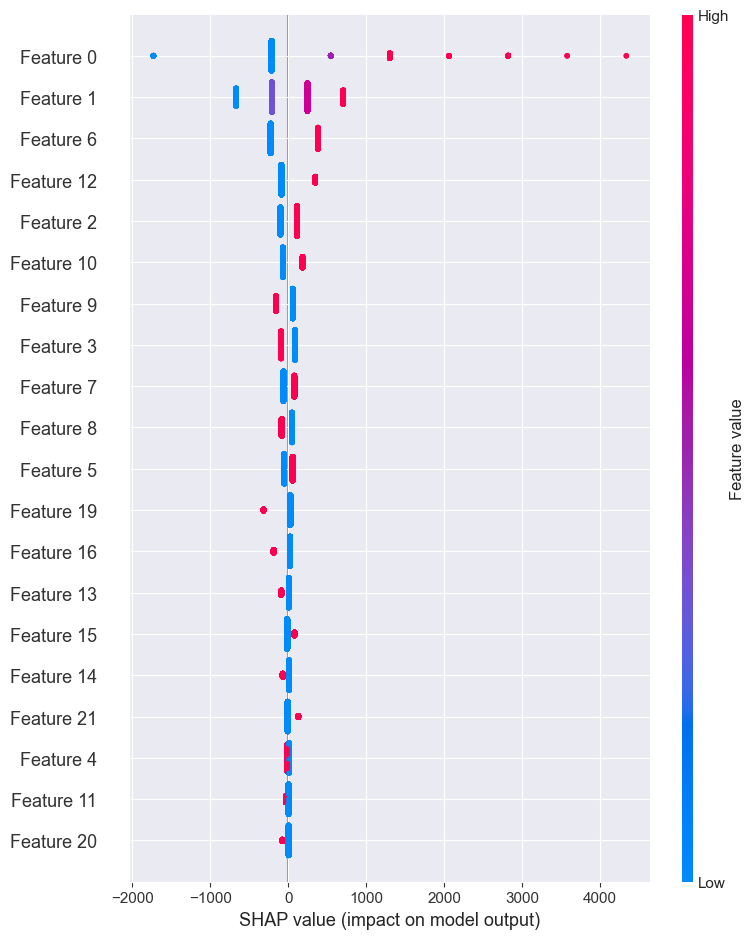

In [57]:
model = pipe.named_steps['lasso']
scaler = pipe.named_steps['min_max_scaler']

X_test_scaled = scaler.transform(X_test)

explainer = shap.LinearExplainer(model, X_test_scaled)
shap_vals = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_vals, X_test_scaled)

In [58]:
shap_vals

array([[-212.17983754, -210.35931281, -100.48915769, ...,   27.49038417,
           5.64935718,   -6.83091714],
       [-212.17983754, -210.35931281,  113.3175608 , ..., -316.13941801,
           5.64935718,   -6.83091714],
       [1303.39043058,  246.94354113,  113.3175608 , ...,   27.49038417,
           5.64935718,   -6.83091714],
       ...,
       [-212.17983754, -667.66216676,  113.3175608 , ...,   27.49038417,
           5.64935718,   -6.83091714],
       [-212.17983754, -667.66216676,  113.3175608 , ..., -316.13941801,
           5.64935718,   -6.83091714],
       [-212.17983754, -210.35931281, -100.48915769, ...,   27.49038417,
           5.64935718,   -6.83091714]], shape=(9263, 22))

In [59]:
feature_importance = np.abs(shap_vals).mean(axis=0)
feature_importance

array([4.06640118e+02, 3.86888187e+02, 1.07171339e+02, 8.97484026e+01,
       1.10823464e+01, 5.39718577e+01, 2.90412065e+02, 6.80638363e+01,
       6.12657939e+01, 9.20694526e+01, 9.88768062e+01, 9.39221614e+00,
       1.30057492e+02, 1.93127553e+01, 1.81006238e+01, 1.84189899e+01,
       3.73160816e+01, 2.09622017e-01, 0.00000000e+00, 4.19493231e+01,
       9.26091705e+00, 1.18086447e+01])

In [60]:
imp_dict = pd.DataFrame({'feature_name': X_train.columns, 'shap_values': feature_importance})
imp_dict.sort_values(by='shap_values', ascending=False, inplace=True)
imp_dict = imp_dict.head(10)
imp_dict

,feature_name,shap_values
0,bathrooms,406.640118
1,bedrooms,386.888187
6,Doorman,290.412065
12,LaundryinUnit,130.057492
2,Elevator,107.171339
10,FitnessCenter,98.876806
9,LaundryinBuilding,92.069453
3,HardwoodFloors,89.748403
7,Dishwasher,68.063836
8,NoFee,61.265794


In [61]:
shap_features = list(imp_dict['feature_name'])
shap_features

['bathrooms',
 'bedrooms',
 'Doorman',
 'LaundryinUnit',
 'Elevator',
 'FitnessCenter',
 'LaundryinBuilding',
 'HardwoodFloors',
 'Dishwasher',
 'NoFee']

In [62]:
X_new = X[shap_features]
X_new

,bathrooms,bedrooms,Doorman,LaundryinUnit,Elevator,FitnessCenter,LaundryinBuilding,HardwoodFloors,Dishwasher,NoFee
4,1.0,1,0,0,0,0,1,1,1,0
6,1.0,2,1,0,1,0,1,1,1,1
9,1.0,2,1,1,1,0,1,1,1,0
10,1.5,3,0,0,0,0,0,0,0,0
15,1.0,0,1,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,0,0,1,0,0,1,1,0
124002,1.0,2,1,0,1,0,0,0,0,1
124004,1.0,1,0,1,1,0,1,1,1,1
124008,1.0,2,0,1,0,0,0,0,1,1


In [63]:
X_train, X_test, y_train, y_test = my_train_test_split(X_new, y, random_state=21)
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)
MAE = mean_absolute_error(y_test, preds)
RMSE = np.sqrt(mean_squared_error(y_test, preds))
R2 = r2_score(y_test, preds)
print(MAE)
print(RMSE)
print(R2)

692.8052413515821
1002.5580687652239
0.5377698674606501


## 7.Hyperparameter optimization

#### Implement grid search and random search methods for alpha and l1_ratio for sklearn's ElasticNet model.

In [64]:
class myGridSearch():
    def __init__(self, param_grid):
        self.param_grid = param_grid

    def process(self, X, y):
        myKF = MyKFold(k_splits=5)
        keys = self.param_grid.keys()
        values = self.param_grid.values()
        comb_dicts = []
        combs = list(product(*values))
        for comb in combs:
            comb_dicts.append(dict(zip(keys, comb)))

        mae_results = []
        comb = []
        for comb_dict in comb_dicts:
            mae_fold = []
            for train_index, test_index in myKF.split(X):
                scaler = MinMaxScaler()
                X_train_fold = scaler.fit_transform(X.iloc[train_index])
                X_test_fold = scaler.transform(X.iloc[test_index])
                sklearn_elnet = ElasticNet()
                sklearn_elnet.set_params(**comb_dict)
                sklearn_elnet.fit(X_train_fold, y.iloc[train_index])
                pred_fold = sklearn_elnet.predict(X_test_fold)
                mae_fold.append(mean_absolute_error(y.iloc[test_index], pred_fold))
            mae_results.append(np.mean(mae_fold))
            comb.append(comb_dict)
        best_index = np.argmin(mae_results)
        best_params = comb[best_index]
        best_mae = mae_results[best_index]
        self.best_params = best_params
        self.best_mae = best_mae



In [65]:
class myRandomSearch():
    def __init__(self, param_grid, n_iter=10):
        self.param_grid = param_grid
        self.n_iter = n_iter

    def process(self, X, y):
        myKF = MyKFold(k_splits=5)
        mae_results = []
        params_overall = []
        for _ in range(self.n_iter):
            params = {}
            mae_fold = []
            for aquakey, (low, high) in self.param_grid.items():
                params[aquakey] = np.random.uniform(low, high)
            for train_index, test_index in myKF.split(X):
                scaler = MinMaxScaler()
                X_train_fold = scaler.fit_transform(X.iloc[train_index])
                X_test_fold = scaler.transform(X.iloc[test_index])
                sklearn_elnet = ElasticNet()
                sklearn_elnet.set_params(**params)
                sklearn_elnet.fit(X_train_fold, y.iloc[train_index])
                pred_fold = sklearn_elnet.predict(X_test_fold)
                mae_fold.append(mean_absolute_error(y.iloc[test_index], pred_fold))
            mae_results.append(np.mean(mae_fold))
            params_overall.append(params)
        best_index = np.argmin(mae_results)
        best_params = params_overall[best_index]
        best_mae = mae_results[best_index]
        self.best_params = best_params
        self.best_mae = best_mae

#### Find the best combination of model hyperparameters.

In [66]:
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8, 0.9]
}
gridsearch = myGridSearch(param_grid)
gridsearch.process(X, y)

print(gridsearch.best_params)
print(gridsearch.best_mae)

{'alpha': 0.0001, 'l1_ratio': 0.9}
689.5454653963718


In [67]:
param_grid = {
    'alpha': (0.00001, 0.1),
    'l1_ratio': (0.93, 1.0)
}
randsearch = myRandomSearch(param_grid, n_iter=50)
randsearch.process(X, y)

print(randsearch.best_params)
print(randsearch.best_mae)

{'alpha': 0.003624406180168744, 'l1_ratio': 0.9966119286746874}
689.5489327622956


#### Import optuna and configure the same experiment with ElasticNet.


In [68]:
X

,bathrooms,bedrooms,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,0,1,1,1,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,1,1,0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,1,1,0,0,1,1,0,1,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
124002,1.0,2,1,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
124004,1.0,1,1,1,1,1,0,1,1,1,...,1,0,0,1,0,0,0,0,0,0
124008,1.0,2,0,0,0,0,0,1,1,0,...,1,0,1,0,0,0,0,0,0,0


In [69]:
y

4         2400
6         3800
9         3495
10        3000
15        2795
          ... 
124000    2800
124002    2395
124004    1850
124008    4195
124009    4280
Name: price, Length: 46317, dtype: int64

In [73]:
def obj(trial):
    alpha = trial.suggest_float('alpha', 0.0001, 1.0)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)

    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

    mae_fold = []
    myKF = MyKFold(k_splits=5)
    for train_index, test_index in myKF.split(X):
        scaler = MinMaxScaler()
        X_train_fold = scaler.fit_transform(X.iloc[train_index])
        X_test_fold = scaler.transform(X.iloc[test_index])
        model.fit(X_train_fold, y.iloc[train_index])
        predict_fold = model.predict(X_test_fold)
        mae_fold.append(mean_absolute_error(y.iloc[test_index], predict_fold))
    return np.mean(mae_fold)

In [75]:
study = optuna.create_study(direction='minimize')
study.optimize(obj, n_trials=200)
print(study.best_params)
print(study.best_value)

[I 2026-05-11 22:05:48,872] A new study created in memory with name: no-name-8bf8b472-846f-422a-97cd-358b8352c018
[I 2026-05-11 22:05:49,410] Trial 0 finished with value: 860.4693819187775 and parameters: {'alpha': 0.2858323450555171, 'l1_ratio': 0.3396762379431585}. Best is trial 0 with value: 860.4693819187775.
[I 2026-05-11 22:05:49,864] Trial 1 finished with value: 875.3632613806783 and parameters: {'alpha': 0.3531136789266261, 'l1_ratio': 0.3435106359871066}. Best is trial 0 with value: 860.4693819187775.
[I 2026-05-11 22:05:50,348] Trial 2 finished with value: 944.839801375087 and parameters: {'alpha': 0.6981624038582925, 'l1_ratio': 0.038773793756001096}. Best is trial 0 with value: 860.4693819187775.
[I 2026-05-11 22:05:51,398] Trial 3 finished with value: 749.6500193798895 and parameters: {'alpha': 0.2599052683374238, 'l1_ratio': 0.9608277036420666}. Best is trial 3 with value: 749.6500193798895.
[I 2026-05-11 22:05:51,827] Trial 4 finished with value: 836.4669289390667 and pa

{'alpha': 0.05739011947364317, 'l1_ratio': 0.9999999039756841}
689.4998135786092
